In [1]:
%load_ext autoreload 
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src import config as cfg
from src import data

In [2]:
X, y, names = data.load_spambase()
print(f"X: {X.shape}, features ({len(names)}): {names})")
print(f"Spam: {np.mean(y==1):.3f}")

Spambase: 4601 rows, 391 duplicates removed
X: (4210, 57), features (57): ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_fr

In [3]:
for name in cfg.DATASETS:
    s = data.get_split(name)
    folds = data.stratified_kfold(s["y_train"])
    print(f"\n{name}: train {len(s['y_train'])}, test {len(s['y_test'])}")
    print(f"   +1: train {np.mean(s['y_train'] == 1):.3f}, test {np.mean(s['y_test'] == 1):.3f}")
    print("   +1 in folds:",
          np.round([np.mean(s["y_train"][va] == 1) for _, va in folds], 3))
    val_all = np.sort(np.concatenate([va for _, va in folds]))
    assert np.array_equal(val_all, np.arange(len(s["y_train"])))          
    assert all(np.intersect1d(tr, va).size == 0 for tr, va in folds)   
    if "yclean_train" in s:
        y_all, yclean_all = np.r_[s["y_train"], s["y_test"]], np.r_[s["yclean_train"], s["yclean_test"]]
        print(f"   flip: {np.mean(y_all != yclean_all):.3f} (eta = {cfg.ETA}), "
              f"    clean +1: {np.mean(yclean_all == 1):.3f}")


spambase: train 3368, test 842
   +1: train 0.399, test 0.399
   +1 in folds: [0.399 0.399 0.399 0.398 0.398]

oblique: train 1000, test 250
   +1: train 0.493, test 0.492
   +1 in folds: [0.493 0.493 0.495 0.492 0.492]
   flip: 0.094 (eta = 0.1),     clean +1: 0.486

circles: train 1000, test 250
   +1: train 0.505, test 0.504
   +1 in folds: [0.505 0.505 0.505 0.505 0.505]
   flip: 0.094 (eta = 0.1),     clean +1: 0.497


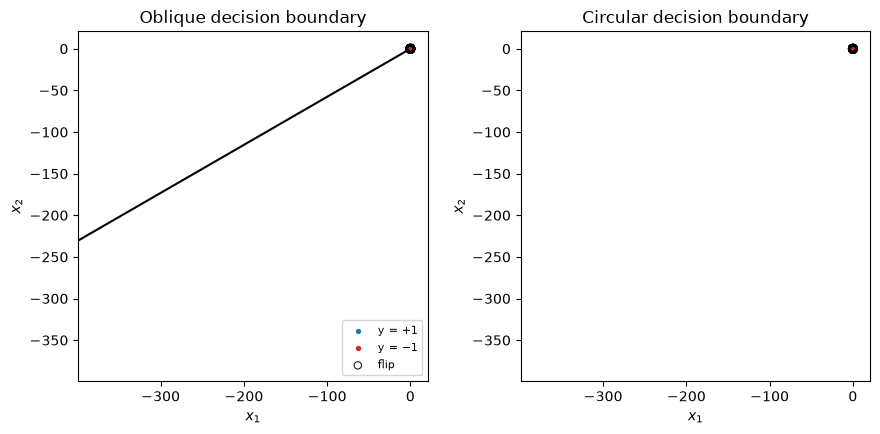

In [5]:
g = np.linspace(-1,1-400)
G1, G2 = np.meshgrid(g,g)
grid = np.c_[G1.ravel(), G2.ravel()]

fig, axes = plt.subplots(1,2,figsize=(9,4.3))

for ax, kind, title in zip(axes, ("oblique", "circles"), ("Oblique decision boundary", "Circular decision boundary")):
    X, y, yc = data.load_synthetic(kind)
    flip = y != yc
    ax.scatter(*X[y == 1].T, s=8, c="tab:blue", label="y = +1")
    ax.scatter(*X[y == -1].T, s=8, c="tab:red", label="y = −1")
    ax.scatter(*X[flip].T, s=28, facecolors="none", edgecolors="k", lw=0.7, label="flip")
    ax.contour(G1, G2, data.boundary_score(grid, kind).reshape(G1.shape),
               levels=[0], colors="k", linewidths=1.5)
    ax.set(title=title, xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
axes[0].legend(loc="lower right", fontsize=8)
fig.tight_layout()
#fig.savefig(cfg.FIG_DIR / "synthetic_datasets.pdf", bbox_inches="tight")
plt.show()
